In [ ]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 32.67 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops

In [ ]:
!ls -R '/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops'

'/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops':
Crop___Disease

'/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease':
Corn  Potato  Rice  Wheat

'/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn':
Corn___Common_Rust     Corn___Healthy
Corn___Gray_Leaf_Spot  Corn___Northern_Leaf_Blight

'/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn/Corn___Common_Rust':
'image (1000).JPG'  'image (196).JPG'  'image (464).JPG'  'image (732).JPG'
'image (1001).JPG'  'image (197).JPG'  'image (465).JPG'  'image (733).JPG'
'image (1002).JPG'  'image (198).JPG'  'image (466).JPG'  'image (734).JPG'
'image (1003).JPG'  'image (199).JPG'  'image (467).JPG'  'image (735).JPG'
'image (1004).JPG'  'image (19).JPG'   'image (468).JPG'  'image (736).JPG'
'image (1005).JPG'  'image (1).JPG'    'image (469).JPG'  'image (737).JPG'
'

In [ ]:
import tensorflow as tf

DATA_DIR = '/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops'

# Load a small sample of the training data to get class names and a batch shape
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}/Crop___Disease', # Changed 'train' to 'Crop___Disease'
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224), # Common image size for models
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

class_names = train_ds.class_names

print(f"Dataset content type: Image Dataset")
print(f"Class names: {class_names}")

# Get one batch to inspect its shape
for image_batch, labels_batch in train_ds.take(1):
    print(f"Shape of a sample batch (images): {image_batch.shape}")
    print(f"Shape of a sample batch (labels): {labels_batch.shape}")
    break

Found 7892 files belonging to 4 classes.
Dataset content type: Image Dataset
Class names: ['Corn', 'Potato', 'Rice', 'Wheat']
Shape of a sample batch (images): (32, 224, 224, 3)
Shape of a sample batch (labels): (32, 4)


In [ ]:
import tensorflow as tf

DATA_DIR = '/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn'

# Load a small sample of the training data to get class names and a batch shape
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{DATA_DIR}', # Removed '/Crop___Disease' as DATA_DIR already points to the correct directory
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224), # Common image size for models
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

class_names = train_ds.class_names

print(f"Dataset content type: Image Dataset")
print(f"Class names: {class_names}")

# Get one batch to inspect its shape
for image_batch, labels_batch in train_ds.take(1):
    print(f"Shape of a sample batch (images): {image_batch.shape}")
    print(f"Shape of a sample batch (labels): {labels_batch.shape}")
    break

Found 3852 files belonging to 4 classes.
Dataset content type: Image Dataset
Class names: ['Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Northern_Leaf_Blight']
Shape of a sample batch (images): (32, 224, 224, 3)
Shape of a sample batch (labels): (32, 4)


In [ ]:
import os
import shutil
from tqdm import tqdm

SOURCE_DIR = "/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease"
TARGET_DIR = "/content/Bangladesh_Disease_Classes"

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP")

os.makedirs(TARGET_DIR, exist_ok=True)

total = 0

for crop in os.listdir(SOURCE_DIR):
    crop_path = os.path.join(SOURCE_DIR, crop)

    if not os.path.isdir(crop_path):
        continue

    for disease in os.listdir(crop_path):
        disease_path = os.path.join(crop_path, disease)

        if not os.path.isdir(disease_path):
            continue

        disease_class_dir = os.path.join(TARGET_DIR, disease)
        os.makedirs(disease_class_dir, exist_ok=True)

        count = 0

        for img in tqdm(os.listdir(disease_path), desc=disease):
            src_img = os.path.join(disease_path, img)

            if os.path.isfile(src_img) and img.endswith(IMG_EXTS):
                new_name = f"{disease}_{count}_{img}"
                dst_img = os.path.join(disease_class_dir, new_name)

                shutil.copy2(src_img, dst_img)
                count += 1
                total += 1

        print(f"{disease}: {count} images copied")

print("\nDONE")
print("Total images copied:", total)
print("Final disease-class dataset:", TARGET_DIR)

Corn___Common_Rust: 100%|██████████| 1192/1192 [00:30<00:00, 39.67it/s] 


Corn___Common_Rust: 1192 images copied


Corn___Northern_Leaf_Blight: 100%|██████████| 985/985 [00:22<00:00, 44.60it/s] 


Corn___Northern_Leaf_Blight: 985 images copied


Corn___Gray_Leaf_Spot: 100%|██████████| 513/513 [00:12<00:00, 41.30it/s] 


...

Potato___Early_Blight: 1000 images copied


Potato___Late_Blight: 0it [00:00, ?it/s]


Potato___Late_Blight: 0 images copied


Potato___Healthy: 100%|██████████| 152/152 [00:02<00:00, 57.89it/s] 

Potato___Healthy: 152 images copied

DONE
Total images copied: 7892
Final disease-class dataset: /content/Bangladesh_Disease_Classes


In [ ]:
import os

SOURCE_DIR = "/content/drive/MyDrive/New Bangladeshi Dataset/BangladeshiCrops/BangladeshiCrops/Crop___Disease"

for crop in os.listdir(SOURCE_DIR):
    crop_path = os.path.join(SOURCE_DIR, crop)
    if not os.path.isdir(crop_path):
        continue

    print("\nCROP:", crop)

    for disease in os.listdir(crop_path):
        disease_path = os.path.join(crop_path, disease)
        if not os.path.isdir(disease_path):
            continue

        files = os.listdir(disease_path)
        print(disease, "=>", len(files), "items")
        print("Sample:", files[:5])


CROP: Corn
Corn___Common_Rust => 1192 items
Sample: ['image (1031).JPG', 'image (1176).JPG', 'image (1190).JPG', 'image (1122).JPG', 'image (1123).JPG']
Corn___Northern_Leaf_Blight => 985 items
Sample: ['image (150).JPG', 'image (13).JPG', 'image (174).jpg', 'image (102).JPG', 'image (230).JPG']
Corn___Gray_Leaf_Spot => 513 items
Sample: ['image (126).jpg', 'image (191).JPG', 'image (188).JPG', 'image (199).JPG', 'image (171).JPG']
Corn___Healthy => 1162 items
Sample: ['image (1122).jpg', 'image (1150).jpg', 'image (1046).jpg', 'image (126).jpg', 'image (132).jpg']

CROP: Rice
Rice___Leaf_Blast => 977 items
Sample: ['IMG_20190419_105702.jpg', 'IMG_20190419_110203.jpg', 'IMG_20190419_103923.jpg', 'IMG_20190419_110245.jpg', 'IMG_20190419_095029.jpg']
Rice___Neck_Blast => 204 items
Sample: ['IMG20201108163525_00.jpg', 'IMG20201108163557_00.jpg', 'IMG20201108163532_00.jpg', 'IMG20201108163519_00.jpg', 'IMG20201108163458_00.jpg']
Rice___Healthy => 1488 items
Sample: ['IMG_20190419_161213.j

In [ ]:
import os
import shutil

TARGET_DIR = "/content/Bangladesh_Disease_Classes"

for cls in os.listdir(TARGET_DIR):
    cls_path = os.path.join(TARGET_DIR, cls)

    if os.path.isdir(cls_path):
        n = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ])

        if n == 0:
            shutil.rmtree(cls_path)
            print("Removed empty class:", cls)

print("Final classes:")
for cls in sorted(os.listdir(TARGET_DIR)):
    cls_path = os.path.join(TARGET_DIR, cls)
    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

Removed empty class: Wheat___Brown_Rust
Removed empty class: Wheat___Yellow_Rust
Removed empty class: Potato___Late_Blight
Removed empty class: Wheat___Healthy
Final classes:
Corn___Common_Rust : 1192
Corn___Gray_Leaf_Spot : 513
Corn___Healthy : 1162
Corn___Northern_Leaf_Blight : 985
Potato___Early_Blight : 1000
Potato___Healthy : 152
Rice___Brown_Spot : 219
Rice___Healthy : 1488
Rice___Leaf_Blast : 977
Rice___Neck_Blast : 204


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
BATCH_SIZE = 32
TARGET_DIR = "/content/Bangladesh_Disease_Classes"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

target_train = datagen.flow_from_directory(
    TARGET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

target_val = datagen.flow_from_directory(
    TARGET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

NUM_CLASSES = len(target_train.class_indices)

print(target_train.class_indices)
print("Number of disease classes:", NUM_CLASSES)

Found 6318 images belonging to 10 classes.
Found 1574 images belonging to 10 classes.
{'Corn___Common_Rust': 0, 'Corn___Gray_Leaf_Spot': 1, 'Corn___Healthy': 2, 'Corn___Northern_Leaf_Blight': 3, 'Potato___Early_Blight': 4, 'Potato___Healthy': 5, 'Rice___Brown_Spot': 6, 'Rice___Healthy': 7, 'Rice___Leaf_Blast': 8, 'Rice___Neck_Blast': 9}
Number of disease classes: 10


In [ ]:
# ===============================================================
# SimCLR + MADA-lite + SE-ResNet + INT8 Quantization
# Source: PlantVillage (6 classes)
# Target: New Bangladeshi Disease Dataset (6 selected classes)
# ===============================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ================= CONFIG =================
IMG_SIZE = 48
BATCH_SIZE = 32
EPOCHS_DA = 20
TEMPERATURE = 0.1

FEATURE_DIM = 64
PROJECTION_DIM = 64
NUM_DOMAINS = 2

# ---- UPDATED PATHS ----
SOURCE_DIR = "/content/PlantVillage-Dataset/raw/segmented"
TARGET_DIR = "/content/Bangladesh_Disease_Classes"

SOURCE_CLASSES = [
    "Tomato___Bacterial_spot",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Early_blight",
    "Corn_(maize)___Cercospora_leaf_spot_Gray_leaf_spot",
    "Tomato___Septoria_leaf_spot",
    "Strawberry___Leaf_scorch"
]

# ---- NEW BANGLADESHI DATASET: 6 SELECTED TARGET CLASSES ----
TARGET_CLASSES = [
    "Corn___Common_Rust",
    "Corn___Gray_Leaf_Spot",
    "Corn___Healthy",
    "Corn___Northern_Leaf_Blight",
    "Potato___Early_Blight",
    "Rice___Leaf_Blast"
]

# ================= CHECK TARGET CLASSES =================
print("Checking target classes:")
for cls in TARGET_CLASSES:
    cls_path = os.path.join(TARGET_DIR, cls)
    if os.path.exists(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))
    else:
        print("Missing:", cls)

# ================= GRADIENT REVERSAL =================
@tf.custom_gradient
def grad_reverse(x, lambd):
    def grad(dy):
        return -lambd * dy, None
    return x, grad

class GradientReversal(layers.Layer):
    def __init__(self):
        super().__init__()
        self.lambd = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    def call(self, x):
        return grad_reverse(x, self.lambd)

# ================= AUGMENTATION =================
def strong_aug(x):
    x = tf.image.random_brightness(x, 0.5)
    x = tf.image.random_contrast(x, 0.6, 1.4)
    x = tf.image.random_flip_left_right(x)
    return tf.clip_by_value(x, 0, 1)

def weak_aug(x):
    x = tf.image.random_brightness(x, 0.3)
    x = tf.image.random_contrast(x, 0.8, 1.2)
    return tf.clip_by_value(x, 0, 1)

def create_views(img, is_source):
    img = tf.cast(img, tf.float32) / 255.0
    aug = strong_aug if is_source else weak_aug
    return aug(img), aug(img)

# ================= DATA GENERATOR =================
def combined_generator():
    datagen = ImageDataGenerator()

    s_gen = datagen.flow_from_directory(
        SOURCE_DIR,
        classes=SOURCE_CLASSES,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE // 2,
        shuffle=True,
        class_mode=None
    )

    t_gen = datagen.flow_from_directory(
        TARGET_DIR,
        classes=TARGET_CLASSES,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE // 2,
        shuffle=True,
        class_mode=None
    )

    while True:
        xs = next(s_gen)
        xt = next(t_gen)

        X = np.concatenate([xs, xt], axis=0)

        domain = tf.concat([
            tf.zeros(xs.shape[0], dtype=tf.int32),
            tf.ones(xt.shape[0], dtype=tf.int32)
        ], axis=0)

        v1, v2 = [], []

        for i, img in enumerate(X):
            a, b = create_views(img, i < xs.shape[0])
            v1.append(a)
            v2.append(b)

        yield (tf.stack(v1), tf.stack(v2)), domain

# ================= SE BLOCK =================
def se_block(x, ratio=8):
    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 1), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)

    return layers.multiply([x, se])

# ================= RESIDUAL BLOCK =================
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

# ================= ENCODER =================
def build_encoder():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(16, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for f, s in zip([32, 32, 64, 64, 128, 128], [1, 1, 2, 1, 2, 1]):
        x = residual_block(x, f, s)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(FEATURE_DIM, activation='relu', name='shared_features')(x)

    return models.Model(inp, x)

# ================= HEADS =================
def projection_head():
    inp = layers.Input((FEATURE_DIM,))
    x = layers.Dense(32, activation='relu')(inp)
    out = layers.Dense(PROJECTION_DIM)(x)
    return models.Model(inp, out)

def domain_head(grl):
    inp = layers.Input((FEATURE_DIM,))
    x = grl(inp)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(NUM_DOMAINS, activation='softmax')(x)
    return models.Model(inp, out)

# ================= NT-XENT LOSS =================
def nt_xent(z1, z2):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)

    z = tf.concat([z1, z2], axis=0)
    sim = tf.matmul(z, z, transpose_b=True)

    sim -= tf.eye(tf.shape(z)[0]) * 1e9

    bs = tf.shape(z1)[0]
    labels = tf.concat([tf.range(bs, 2 * bs), tf.range(bs)], axis=0)

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels,
        sim / TEMPERATURE,
        from_logits=True
    )

    return tf.reduce_mean(loss)

# ================= SIMCLR + DA MODEL =================
class SimCLR_DA(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.encoder = build_encoder()
        self.projector = projection_head()
        self.grl = GradientReversal()
        self.domain = domain_head(self.grl)

    def train_step(self, data):
        (v1, v2), dom = data

        with tf.GradientTape() as tape:
            h1 = self.encoder(v1, training=True)
            h2 = self.encoder(v2, training=True)

            z1 = self.projector(h1, training=True)
            z2 = self.projector(h2, training=True)

            loss_c = nt_xent(z1, z2)

            dom_pred = self.domain(tf.concat([h1, h2], axis=0), training=True)

            loss_d = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    tf.concat([dom, dom], axis=0),
                    dom_pred
                )
            )

            loss = loss_c + loss_d

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {
            "contrastive_loss": loss_c,
            "domain_loss": loss_d,
            "total_loss": loss
        }

# ================= TRAIN DA =================
model = SimCLR_DA()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4))

gen = combined_generator()

for epoch in range(EPOCHS_DA):
    model.grl.lambd.assign(min(1.0, epoch / 10.0))
    print(f"Epoch {epoch + 1} | Lambda = {model.grl.lambd.numpy():.2f}")
    model.fit(gen, steps_per_epoch=200, epochs=1)

model.encoder.save("encoder_da_bangladesh_6class.h5")

# ================= LINEAR EVALUATION =================
model.encoder.trainable = False

classifier = tf.keras.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    model.encoder,
    layers.Dense(len(TARGET_CLASSES), activation='softmax')
])

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    TARGET_DIR,
    classes=TARGET_CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    subset='training',
    class_mode='categorical',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    TARGET_DIR,
    classes=TARGET_CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

history = classifier.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

loss, acc = classifier.evaluate(val_gen)
print("Target Accuracy:", acc)

# ================= INT8 QUANTIZATION =================
def representative_data_gen():
    count = 0
    for images, _ in train_gen:
        yield [images.astype(np.float32)]
        count += 1
        if count >= 50:
            break

converter = tf.lite.TFLiteConverter.from_keras_model(classifier)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()

with open("bangladesh_6class_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Training + Quantization Complete")
print("TFLite model saved as: bangladesh_6class_int8.tflite")
print("TFLite size KB:", os.path.getsize("bangladesh_6class_int8.tflite") / 1024)

Checking target classes:
Corn___Common_Rust : 1192
Corn___Gray_Leaf_Spot : 513
Corn___Healthy : 1162
Corn___Northern_Leaf_Blight : 985
Potato___Early_Blight : 1000
Rice___Leaf_Blast : 977
Epoch 1 | Lambda = 0.00
Found 6992 images belonging to 6 classes.
Found 5829 images belonging to 6 classes.
200/200 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - contrastive_loss: 2.0642 - domain_loss: 0.6331 - total_loss: 2.6972
Epoch 2 | Lambda = 0.10
200/200 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - contrastive_loss: 1.5865 - domain_loss: 0.5532 - total_loss: 2.1397
Epoch 3 | Lambda = 0.20
200/200 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - contrastive_loss: 1.5765 - domain_loss: 0.5029 - total_loss: 2.0794
Epoch 4 | Lambda = 0.30
200/200 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - contrastive_loss: 0.9626 - domain_loss: 0.4408 - total_loss: 1.4034
Epoch 5 | Lambda = 0.40
200/200 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - contrastive_loss: 1.0714 - domain_loss: 0.4624 - total_loss: 1.5338
Epoch 6 | Lambda = 0.50
200/200 ━━━━━━━━━━━━━━━━

Found 4665 images belonging to 6 classes.
Found 1164 images belonging to 6 classes.
Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 37s 223ms/step - accuracy: 0.4152 - loss: 1.6281 - val_accuracy: 0.4983 - val_loss: 1.5139
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.6262 - loss: 1.4409 - val_accuracy: 0.6495 - val_loss: 1.3505
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.6887 - loss: 1.3019 - val_accuracy: 0.7345 - val_loss: 1.2296
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.7293 - loss: 1.1947 - val_accuracy: 0.7629 - val_loss: 1.1325
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 218ms/step - accuracy: 0.7586 - loss: 1.1088 - val_accuracy: 0.7706 - val_loss: 1.0559
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.7781 - loss: 1.0377 - val_accuracy: 0.7809 - val_loss: 0.9909
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 33s 226ms/step - accuracy: 0.7874 - loss: 0.9780 - val_accuracy: 0.7852 - val_loss: 0.9360

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Training + Quantization Complete
TFLite model saved as: bangladesh_6class_int8.tflite
TFLite size KB: 137.2578125


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)
from sklearn.preprocessing import label_binarize

# Recreate validation generator with shuffle=False
eval_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen_eval = eval_datagen.flow_from_directory(
    TARGET_DIR,
    classes=TARGET_CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# Reset validation generator
val_gen_eval.reset()

# True labels
y_true = val_gen_eval.classes

# Predicted probabilities
y_prob = classifier.predict(val_gen_eval, verbose=1)

# Predicted labels
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = list(val_gen_eval.class_indices.keys())

print("Classes:", class_names)
print("Validation Accuracy:", accuracy_score(y_true, y_pred))



Found 1164 images belonging to 6 classes.
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step
Classes: ['Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Northern_Leaf_Blight', 'Potato___Early_Blight', 'Rice___Leaf_Blast']
Validation Accuracy: 0.8427835051546392


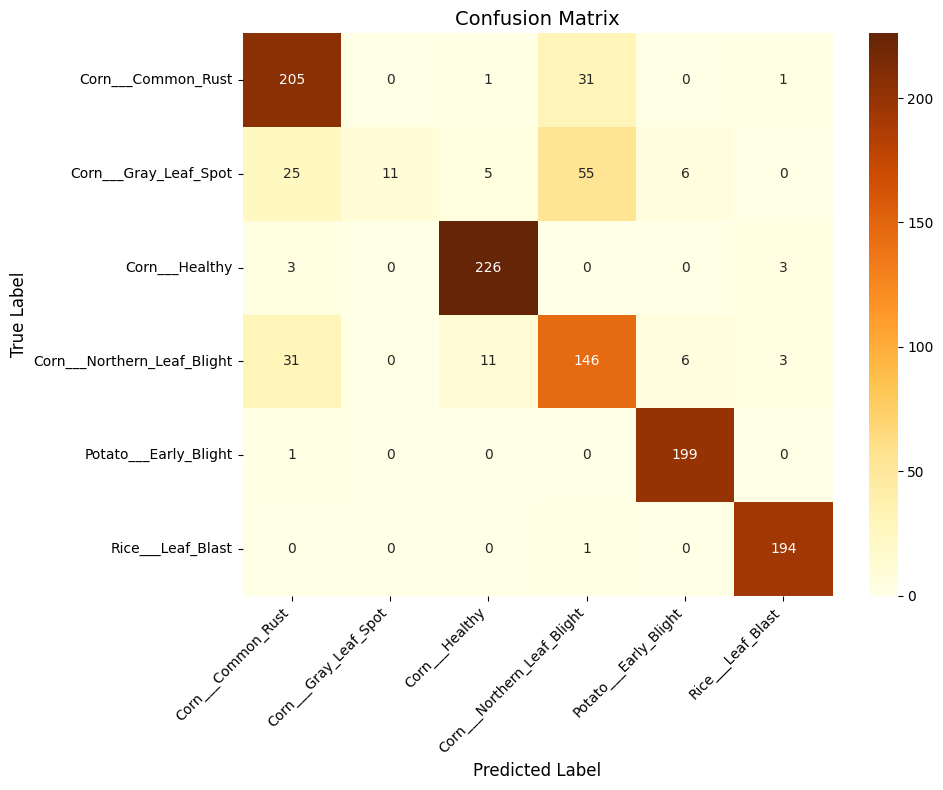

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrBr',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

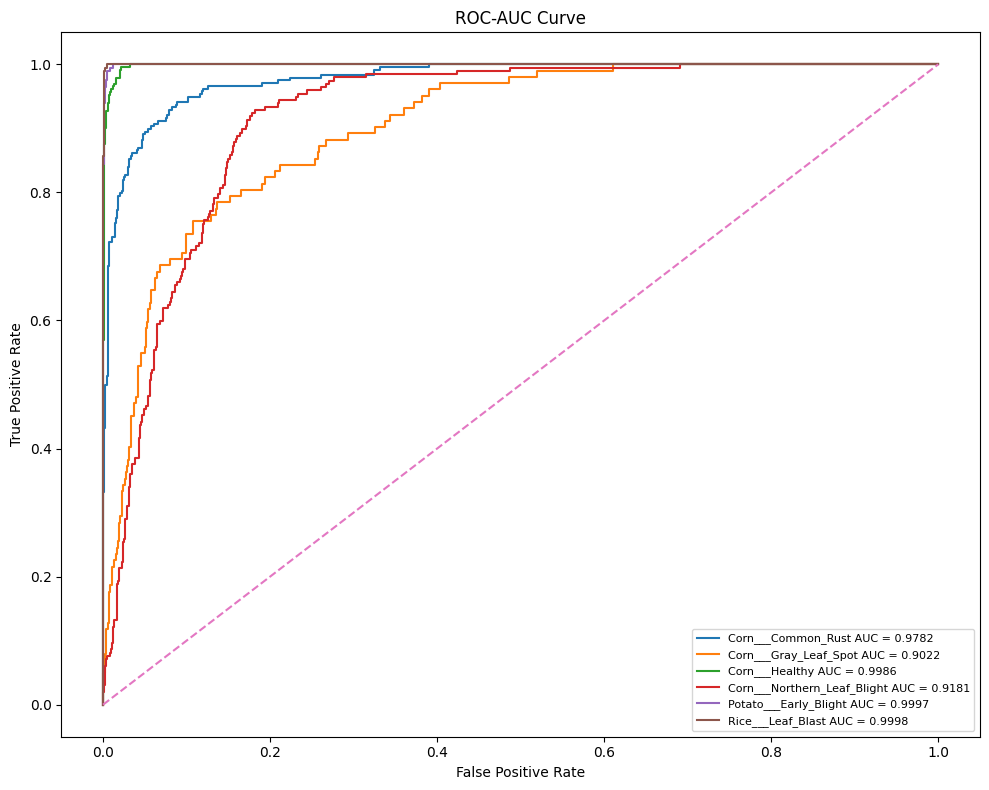


AUC Scores:
Corn___Common_Rust: 0.9782
Corn___Gray_Leaf_Spot: 0.9022
Corn___Healthy: 0.9986
Corn___Northern_Leaf_Blight: 0.9181
Potato___Early_Blight: 0.9997
Rice___Leaf_Blast: 0.9998

Macro ROC-AUC: 0.9661
Weighted ROC-AUC: 0.9727


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = len(class_names)

# Binarize true labels
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 8))

auc_scores = {}

for i in range(num_classes):

    # Skip if validation set has no positive sample for this class
    if np.sum(y_true_bin[:, i]) == 0:
        print(f"Skipping {class_names[i]}: no positive samples in validation set")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    auc_scores[class_names[i]] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for cls, score in auc_scores.items():
    print(f"{cls}: {score:.4f}")

# Macro AUC over available classes only
valid_class_indices = [
    i for i in range(num_classes)
    if np.sum(y_true_bin[:, i]) > 0
]

macro_auc = roc_auc_score(
    y_true_bin[:, valid_class_indices],
    y_prob[:, valid_class_indices],
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true_bin[:, valid_class_indices],
    y_prob[:, valid_class_indices],
    average="weighted",
    multi_class="ovr"
)

print("\nMacro ROC-AUC:", round(macro_auc, 4))
print("Weighted ROC-AUC:", round(weighted_auc, 4))

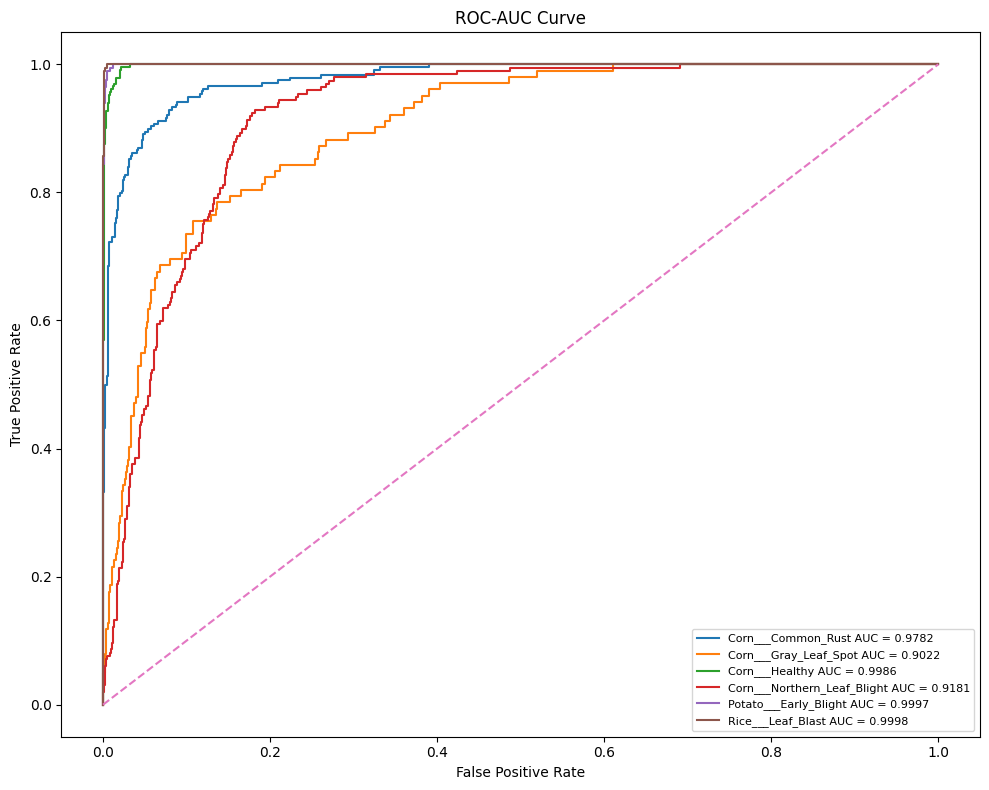


AUC Scores:
Corn___Common_Rust: 0.9782
Corn___Gray_Leaf_Spot: 0.9022
Corn___Healthy: 0.9986
Corn___Northern_Leaf_Blight: 0.9181
Potato___Early_Blight: 0.9997
Rice___Leaf_Blast: 0.9998

Macro ROC-AUC: 0.9661
Weighted ROC-AUC: 0.9727


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = len(class_names)

# Binarize true labels
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 8))

auc_scores = {}

for i in range(num_classes):

    # Skip if validation set has no positive sample for this class
    if np.sum(y_true_bin[:, i]) == 0:
        print(f"Skipping {class_names[i]}: no positive samples in validation set")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    auc_scores[class_names[i]] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} AUC = {roc_auc:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for cls, score in auc_scores.items():
    print(f"{cls}: {score:.4f}")

# Macro AUC over available classes only
valid_class_indices = [
    i for i in range(num_classes)
    if np.sum(y_true_bin[:, i]) > 0
]

macro_auc = roc_auc_score(
    y_true_bin[:, valid_class_indices],
    y_prob[:, valid_class_indices],
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true_bin[:, valid_class_indices],
    y_prob[:, valid_class_indices],
    average="weighted",
    multi_class="ovr"
)

print("\nMacro ROC-AUC:", round(macro_auc, 4))
print("Weighted ROC-AUC:", round(weighted_auc, 4))

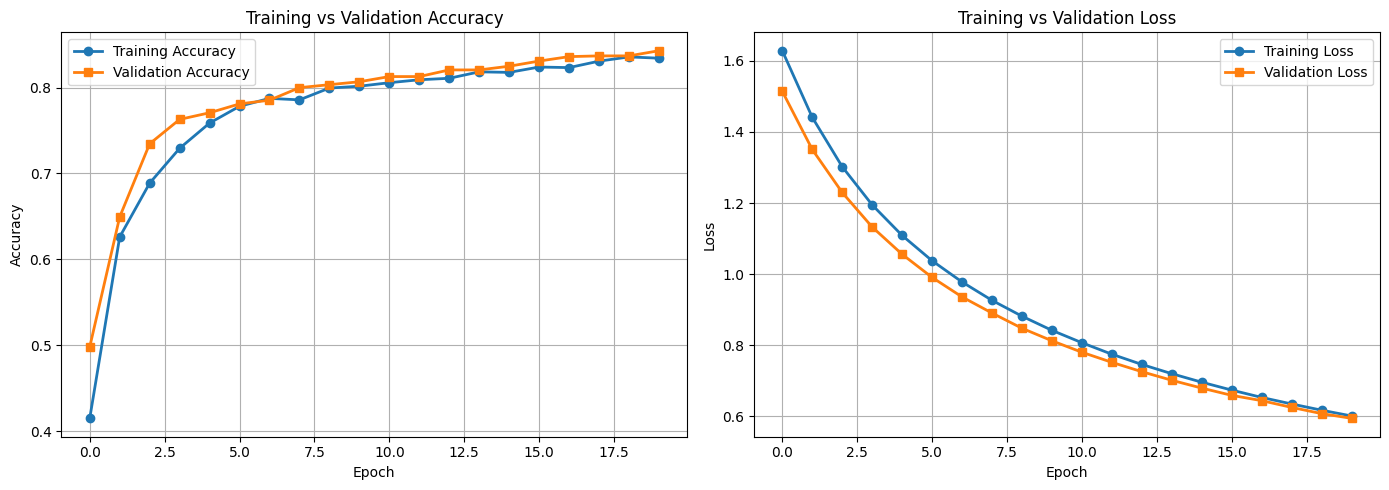

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ================= ACCURACY =================
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# ================= LOSS =================
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()